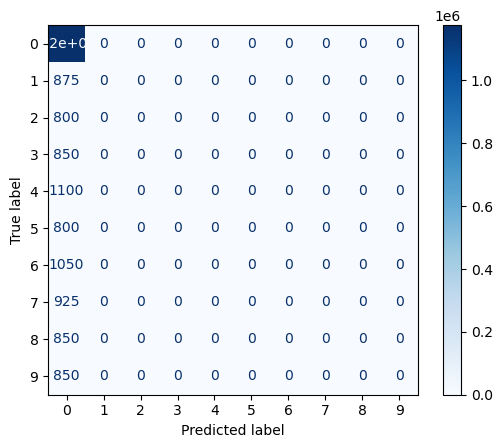

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


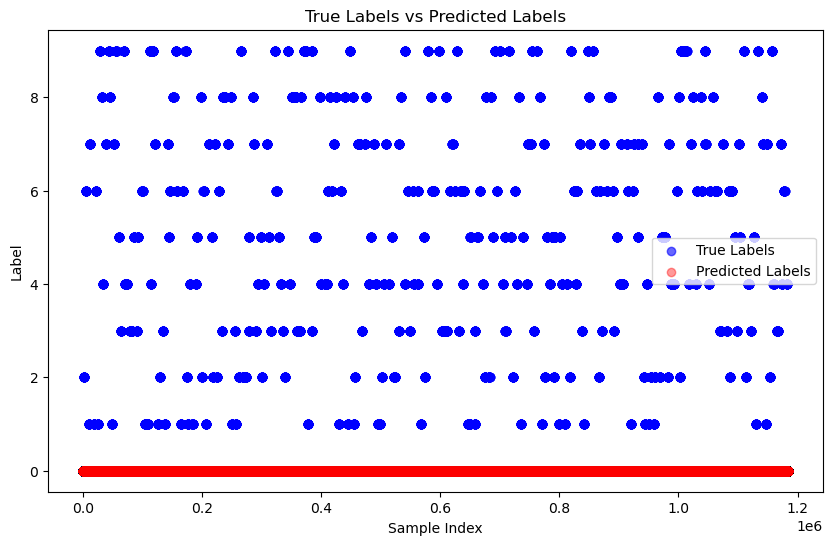

In [7]:
import os
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ----------------------------
# モデル定義 (GCN Model)
# ----------------------------
class GCNModel(torch.nn.Module):
    def __init__(self, hidden_channels=256, num_classes=10):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(4, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv3 = GCNConv(hidden_channels * 2, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, num_classes)
        self.dropout = torch.nn.Dropout(p=0.2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = self.fc(x)
        return x

# ----------------------------
# データペアリング関数 (prepare_data)
# ----------------------------
def prepare_data(pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index):
    data_list = []
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        values = np.load(data_file_path)[:3654]
        label = np.load(label_file_path)[:3654]

        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        x = torch.tensor(node_features, dtype=torch.float)

        y = torch.argmax(torch.tensor(label, dtype=torch.float), dim=1).long()

        data = Data(x=x, edge_index=edge_index, y=y)
        data_list.append(data)
    return data_list

# ----------------------------
# モデルのロードと予測 (load and predict)
# ----------------------------
def load_and_predict(model_path, test_loader, device):
    # モデルをロード
    model = GCNModel(hidden_channels=256, num_classes=10).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # 予測結果と正解ラベルを保存
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            pred = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(batch.y.cpu().numpy())

    # NumPy 配列に変換
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_preds, all_labels

# ----------------------------
# 可視化関数 (Visualization functions)
# ----------------------------
def plot_confusion_matrix(all_labels, all_preds, class_names):
    # 混同行列を作成
    cm = confusion_matrix(all_labels, all_preds)

    # 混同行列を表示
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.show()

def plot_comparison(all_labels, all_preds):
    # 正解ラベルと予測ラベルの比較を散布図で可視化
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(all_labels)), all_labels, label='True Labels', color='blue', alpha=0.6)
    plt.scatter(range(len(all_preds)), all_preds, label='Predicted Labels', color='red', alpha=0.4)
    plt.legend()
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.title('True Labels vs Predicted Labels')
    plt.show()

# ----------------------------
# メインプログラム (Main program)
# ----------------------------
if __name__ == '__main__':
    # デバイス設定
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # モデルのパス
    model_path = "/home/nishioka/GNN/GNNmodel/10classmodel/GCNModel_20241021_155730_Final.pth"

    # テストデータの準備
    standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
    label_data_folder = "/home/nishioka/GNN/Defect10Class_OneHot_test1"
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    edge_index = torch.tensor(np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy").T, dtype=torch.long).to(device)

    # データ準備 (train_test_splitを使用してデータを分割)
    data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
    label_files = [f for f in os.listdir(label_data_folder) if f.startswith("Defect10Class_L")]

    # データペアを作成
    pairs = [(data_files[i], label_files[i]) for i in range(len(data_files))]
    
    # データをトレーニング、テストに分割
    train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

    test_dataset = prepare_data(test_pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 予測
    all_preds, all_labels = load_and_predict(model_path, test_loader, device)

    # 混同行列の可視化
    class_names = [str(i) for i in range(10)]  # クラス名
    plot_confusion_matrix(all_labels, all_preds, class_names)

    # 正解と予測の比較
    plot_comparison(all_labels, all_preds)


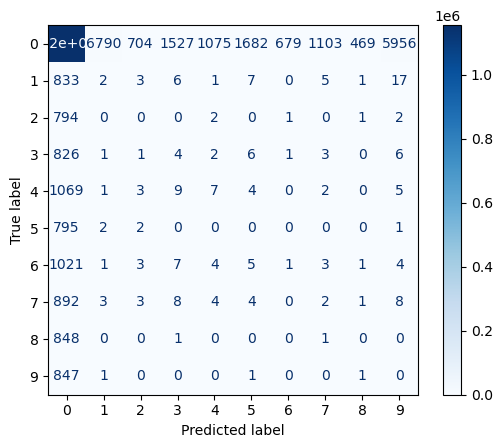

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


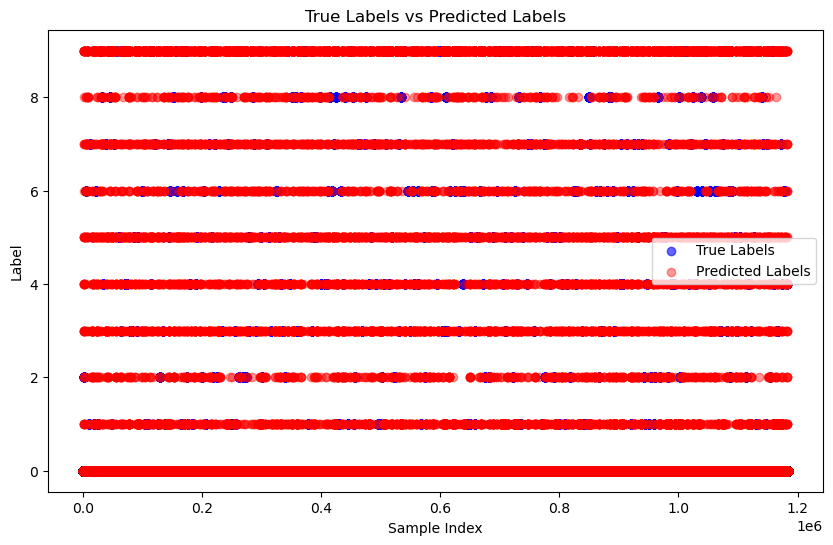

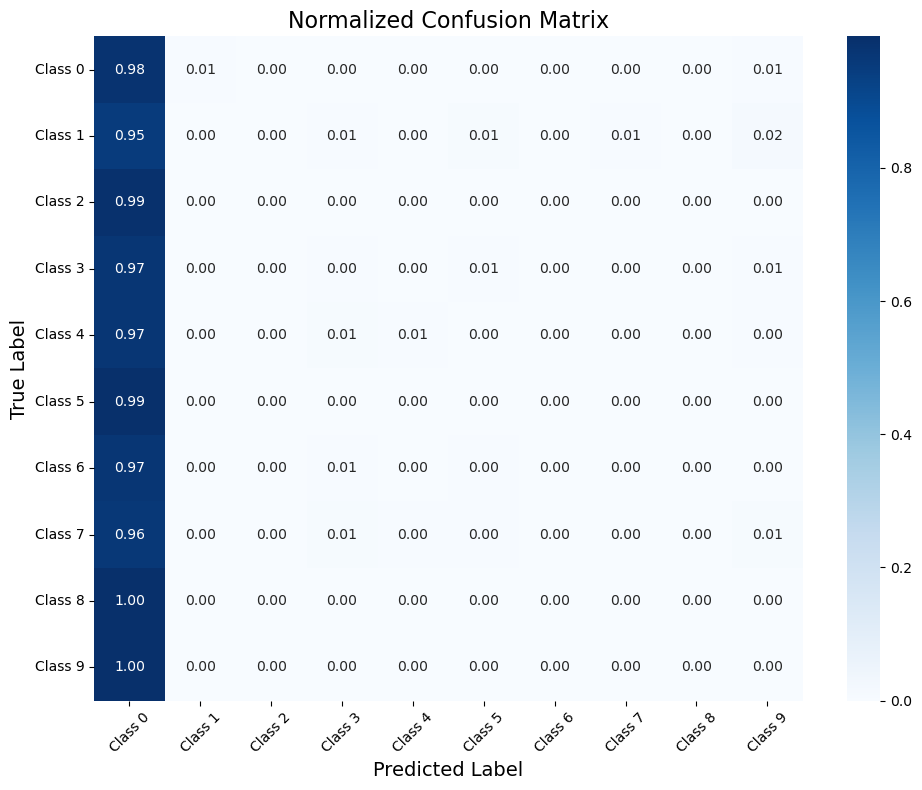

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


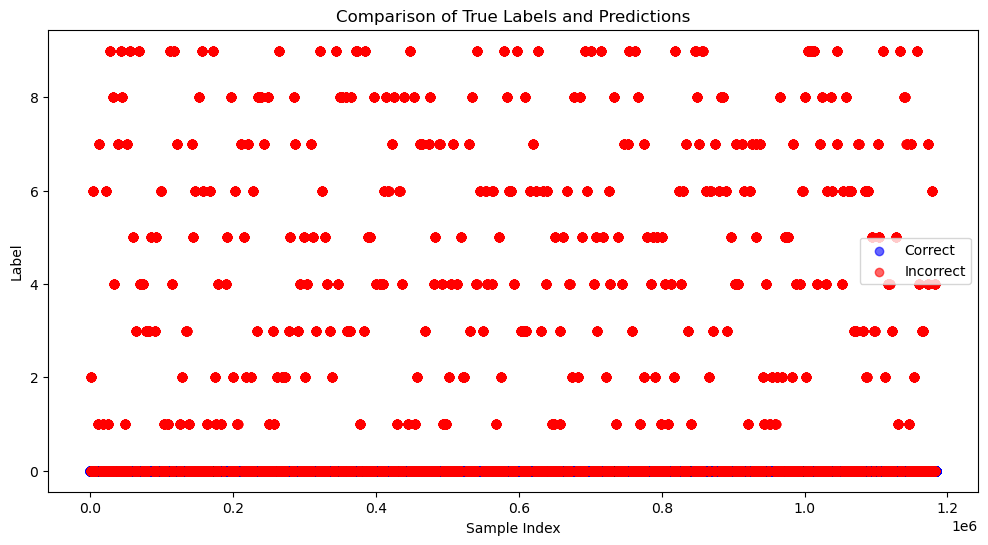

              precision    recall  f1-score   support

     Class 0       0.99      0.98      0.99   1175796
     Class 1       0.00      0.00      0.00       875
     Class 2       0.00      0.00      0.00       800
     Class 3       0.00      0.00      0.00       850
     Class 4       0.01      0.01      0.01      1100
     Class 5       0.00      0.00      0.00       800
     Class 6       0.00      0.00      0.00      1050
     Class 7       0.00      0.00      0.00       925
     Class 8       0.00      0.00      0.00       850
     Class 9       0.00      0.00      0.00       850

    accuracy                           0.98   1183896
   macro avg       0.10      0.10      0.10   1183896
weighted avg       0.99      0.98      0.98   1183896



In [9]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# モデル定義 (GCN Model)
# ----------------------------
class GCNModel(torch.nn.Module):
    def __init__(self, hidden_channels=256, num_classes=10):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(4, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv3 = GCNConv(hidden_channels * 2, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, num_classes)
        self.dropout = torch.nn.Dropout(p=0.2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = self.fc(x)
        return x

# ----------------------------
# データペアリング関数 (prepare_data)
# ----------------------------
def prepare_data(pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index):
    data_list = []
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        values = np.load(data_file_path)[:3654]
        label = np.load(label_file_path)[:3654]

        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        x = torch.tensor(node_features, dtype=torch.float)

        y = torch.argmax(torch.tensor(label, dtype=torch.float), dim=1).long()

        data = Data(x=x, edge_index=edge_index, y=y)
        data_list.append(data)
    return data_list

# ----------------------------
# モデルのロードと予測 (load and predict)
# ----------------------------
def load_and_predict(model_path, test_loader, device):
    # モデルをロード
    model = GCNModel(hidden_channels=256, num_classes=10).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # 予測結果と正解ラベルを保存
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            pred = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(batch.y.cpu().numpy())

    # NumPy 配列に変換
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_preds, all_labels

# ----------------------------
# 可視化関数 (Visualization functions)
# ----------------------------
def plot_confusion_matrix(all_labels, all_preds, class_names):
    # 混同行列を作成
    cm = confusion_matrix(all_labels, all_preds)

    # 混同行列を表示
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.show()

def plot_comparison(all_labels, all_preds):
    # 正解ラベルと予測ラベルの比較を散布図で可視化
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(all_labels)), all_labels, label='True Labels', color='blue', alpha=0.6)
    plt.scatter(range(len(all_preds)), all_preds, label='Predicted Labels', color='red', alpha=0.4)
    plt.legend()
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.title('True Labels vs Predicted Labels')
    plt.show()

# ----------------------------
# メインプログラム (Main program)
# ----------------------------
if __name__ == '__main__':
    # デバイス設定
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # モデルのパス
    model_path = "/home/nishioka/GNN/GNNmodel/10classmodel/GCNModel_20241021_170826_Final.pth"

    # テストデータの準備
    standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
    label_data_folder = "/home/nishioka/GNN/Defect10Class_OneHot_test1"
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    edge_index = torch.tensor(np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy").T, dtype=torch.long).to(device)

    # データ準備 (train_test_splitを使用してデータを分割)
    data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
    label_files = [f for f in os.listdir(label_data_folder) if f.startswith("Defect10Class_L")]

    # データペアを作成
    pairs = [(data_files[i], label_files[i]) for i in range(len(data_files))]
    
    # データをトレーニング、テストに分割
    train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

    test_dataset = prepare_data(test_pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 予測
    all_preds, all_labels = load_and_predict(model_path, test_loader, device)

    # 混同行列の可視化
    class_names = [str(i) for i in range(10)]  # クラス名
    plot_confusion_matrix(all_labels, all_preds, class_names)

    # 正解と予測の比較
    plot_comparison(all_labels, all_preds)
# 混同行列のプロット関数
def plot_confusion_matrix(all_labels, all_preds, class_names):
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.title('Normalized Confusion Matrix', fontsize=16)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 正解と予測の比較プロット
def plot_comparison(all_labels, all_preds):
    correct = all_labels == all_preds
    incorrect = ~correct
    plt.figure(figsize=(12, 6))
    plt.scatter(np.where(correct)[0], all_labels[correct], label='Correct', color='blue', alpha=0.6)
    plt.scatter(np.where(incorrect)[0], all_labels[incorrect], label='Incorrect', color='red', alpha=0.6)
    plt.legend()
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.title('Comparison of True Labels and Predictions')
    plt.show()

# クラス別の評価指標を表示
def print_classification_report(all_labels, all_preds, class_names):
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)

# メインプログラム
if __name__ == '__main__':
    # ...（デバイス設定、モデルロード、データ準備は省略）

    # 予測
    all_preds, all_labels = load_and_predict(model_path, test_loader, device)

    # クラス名（必要に応じて変更）
    class_names = [f'Class {i}' for i in range(10)]

    # 混同行列の可視化
    plot_confusion_matrix(all_labels, all_preds, class_names)

    # 正解と予測の比較
    plot_comparison(all_labels, all_preds)

    # クラス別の評価指標を表示
    print_classification_report(all_labels, all_preds, class_names)


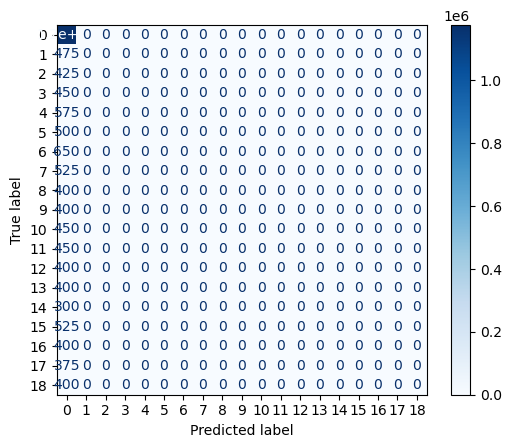

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


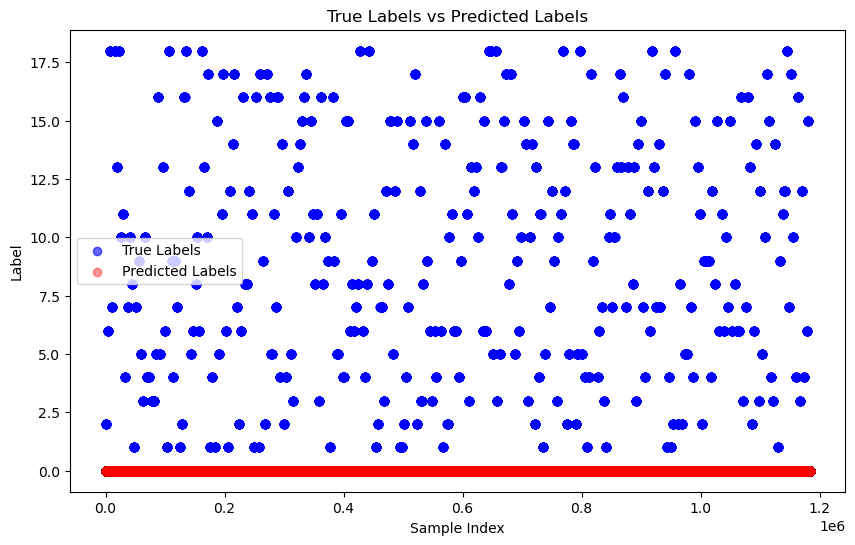

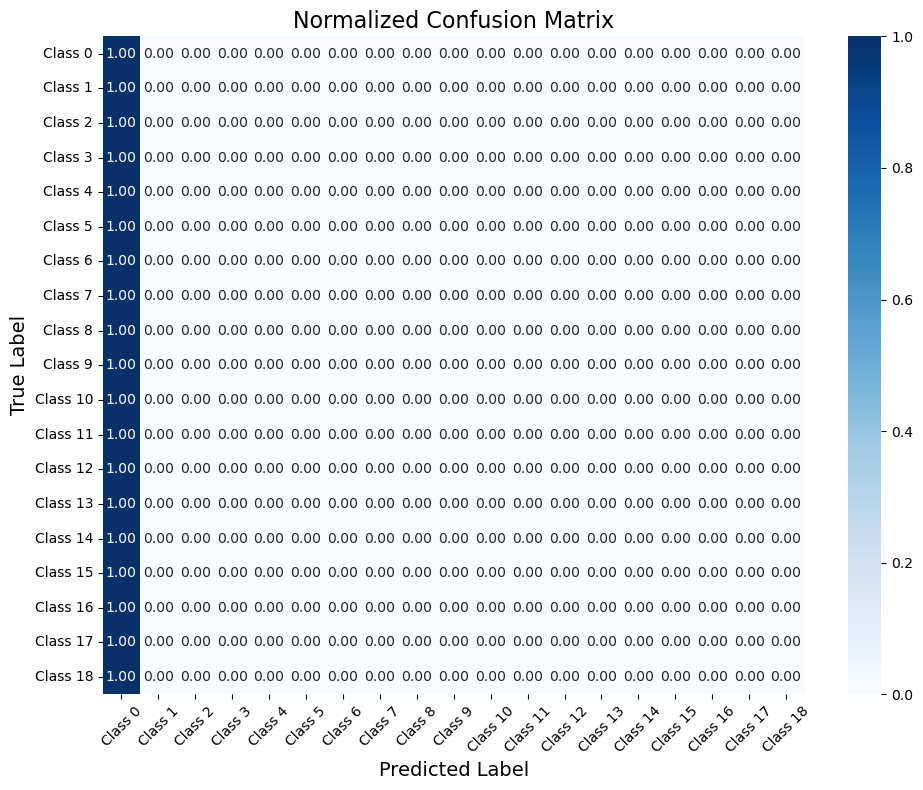

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


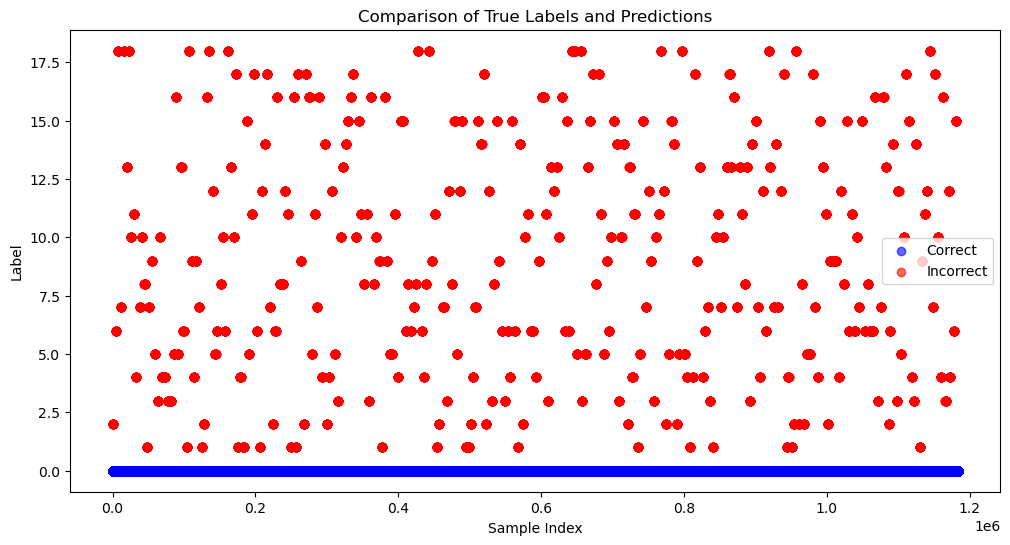

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     Class 0       0.99      1.00      1.00   1175796
     Class 1       0.00      0.00      0.00       475
     Class 2       0.00      0.00      0.00       425
     Class 3       0.00      0.00      0.00       450
     Class 4       0.00      0.00      0.00       575
     Class 5       0.00      0.00      0.00       500
     Class 6       0.00      0.00      0.00       650
     Class 7       0.00      0.00      0.00       525
     Class 8       0.00      0.00      0.00       400
     Class 9       0.00      0.00      0.00       400
    Class 10       0.00      0.00      0.00       450
    Class 11       0.00      0.00      0.00       450
    Class 12       0.00      0.00      0.00       400
    Class 13       0.00      0.00      0.00       400
    Class 14       0.00      0.00      0.00       300
    Class 15       0.00      0.00      0.00       525
    Class 16       0.00      0.00      0.00       400
    Class 17       0.00    

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# モデル定義 (GCN Model)
# ----------------------------
class GCNModel(torch.nn.Module):
    def __init__(self, hidden_channels=64, num_classes=19):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(4, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv3 = GCNConv(hidden_channels * 2, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, num_classes)
        self.dropout = torch.nn.Dropout(p=0.2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = self.fc(x)
        return x

# ----------------------------
# データペアリング関数 (prepare_data)
# ----------------------------
def prepare_data(pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index):
    data_list = []
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        values = np.load(data_file_path)[:3654]
        label = np.load(label_file_path)[:3654]

        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        x = torch.tensor(node_features, dtype=torch.float)

        y = torch.argmax(torch.tensor(label, dtype=torch.float), dim=1).long()

        data = Data(x=x, edge_index=edge_index, y=y)
        data_list.append(data)
    return data_list

# ----------------------------
# モデルのロードと予測 (load and predict)
# ----------------------------
def load_and_predict(model_path, test_loader, device):
    # モデルをロード
    model = GCNModel(hidden_channels=64, num_classes=19).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # 予測結果と正解ラベルを保存
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            pred = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(batch.y.cpu().numpy())

    # NumPy 配列に変換
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_preds, all_labels

# ----------------------------
# 可視化関数 (Visualization functions)
# ----------------------------
def plot_confusion_matrix(all_labels, all_preds, class_names):
    # 混同行列を作成
    cm = confusion_matrix(all_labels, all_preds)

    # 混同行列を表示
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.show()

def plot_comparison(all_labels, all_preds):
    # 正解ラベルと予測ラベルの比較を散布図で可視化
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(all_labels)), all_labels, label='True Labels', color='blue', alpha=0.6)
    plt.scatter(range(len(all_preds)), all_preds, label='Predicted Labels', color='red', alpha=0.4)
    plt.legend()
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.title('True Labels vs Predicted Labels')
    plt.show()

# ----------------------------
# メインプログラム (Main program)
# ----------------------------
if __name__ == '__main__':
    # デバイス設定
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # モデルのパス
    model_path = "/home/nishioka/GNN/GNNmodel/19classmodel/GCNModel_20241029_121024_best_model_fold_5.pth"

    # テストデータの準備
    standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
    label_data_folder = "/home/nishioka/GNN/Defect19Class_OneHot_test2"
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    edge_index = torch.tensor(np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy").T, dtype=torch.long).to(device)

    # データ準備 (train_test_splitを使用してデータを分割)
    data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
    label_files = [f for f in os.listdir(label_data_folder) if f.startswith("Defect19Class_L")]

    # データペアを作成
    pairs = [(data_files[i], label_files[i]) for i in range(len(data_files))]
    
    # データをトレーニング、テストに分割
    train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

    test_dataset = prepare_data(test_pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 予測
    all_preds, all_labels = load_and_predict(model_path, test_loader, device)

    # 混同行列の可視化
    class_names = [str(i) for i in range(19)]  # クラス名
    plot_confusion_matrix(all_labels, all_preds, class_names)

    # 正解と予測の比較
    plot_comparison(all_labels, all_preds)
# 混同行列のプロット関数
def plot_confusion_matrix(all_labels, all_preds, class_names):
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.title('Normalized Confusion Matrix', fontsize=16)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 正解と予測の比較プロット
def plot_comparison(all_labels, all_preds):
    correct = all_labels == all_preds
    incorrect = ~correct
    plt.figure(figsize=(12, 6))
    plt.scatter(np.where(correct)[0], all_labels[correct], label='Correct', color='blue', alpha=0.6)
    plt.scatter(np.where(incorrect)[0], all_labels[incorrect], label='Incorrect', color='red', alpha=0.6)
    plt.legend()
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.title('Comparison of True Labels and Predictions')
    plt.show()

# クラス別の評価指標を表示
def print_classification_report(all_labels, all_preds, class_names):
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)

# メインプログラム
if __name__ == '__main__':
    # ...（デバイス設定、モデルロード、データ準備は省略）

    # 予測
    all_preds, all_labels = load_and_predict(model_path, test_loader, device)

    # クラス名（必要に応じて変更）
    class_names = [f'Class {i}' for i in range(19)]

    # 混同行列の可視化
    plot_confusion_matrix(all_labels, all_preds, class_names)

    # 正解と予測の比較
    plot_comparison(all_labels, all_preds)

    # クラス別の評価指標を表示
    print_classification_report(all_labels, all_preds, class_names)

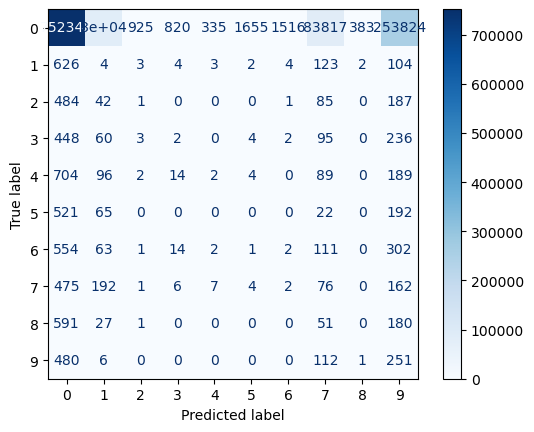

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


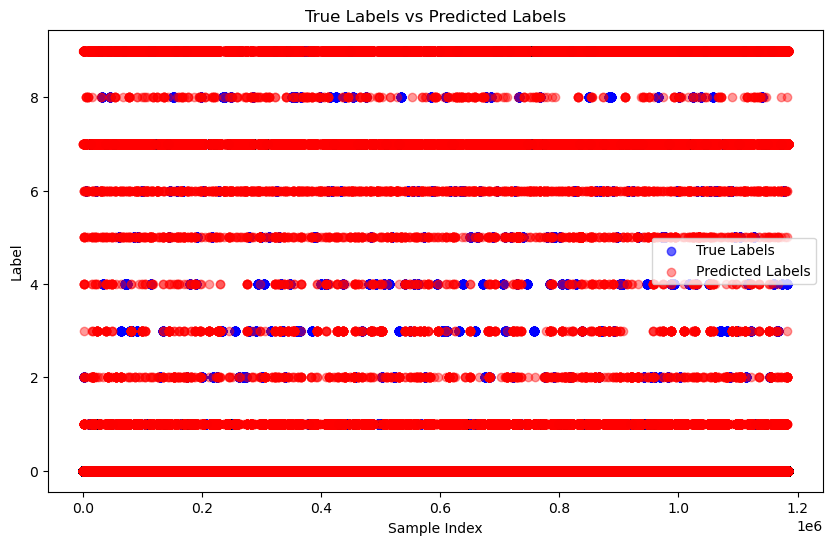

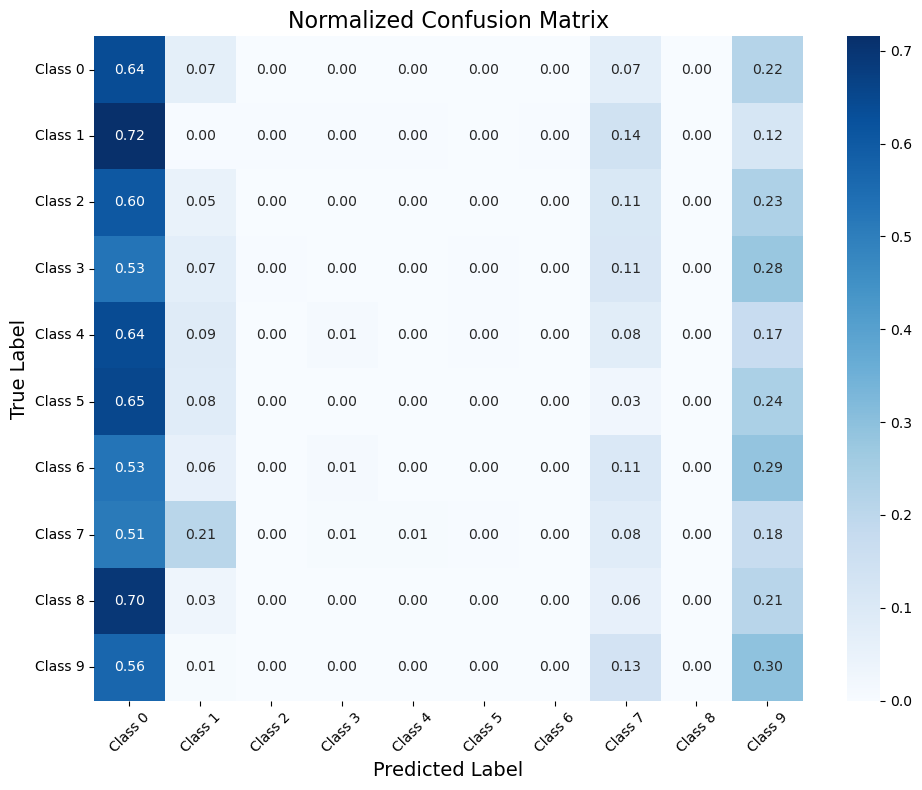

/home/nishioka/miniconda3/envs/interstage_gnn_first/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


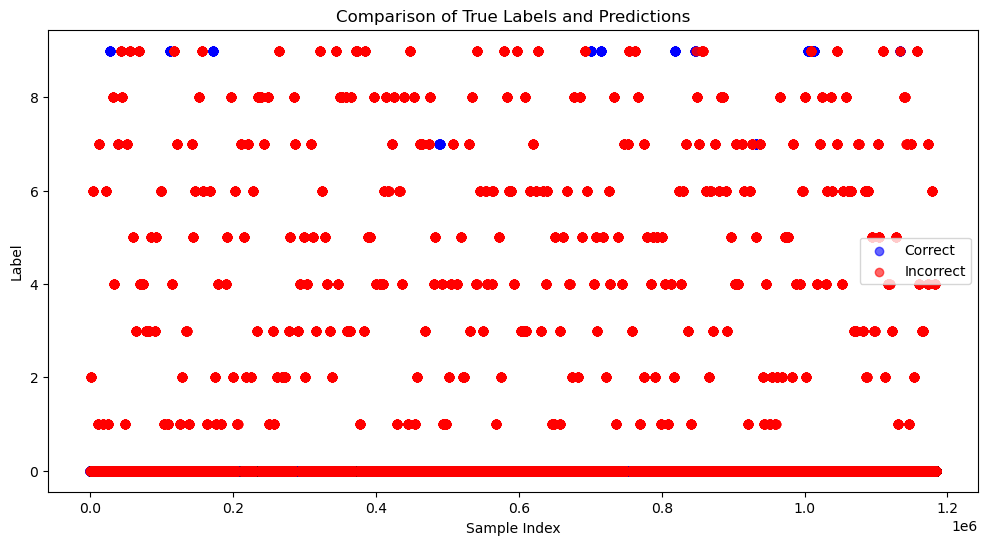

              precision    recall  f1-score   support

     Class 0       0.99      0.64      0.78   1175796
     Class 1       0.00      0.00      0.00       875
     Class 2       0.00      0.00      0.00       800
     Class 3       0.00      0.00      0.00       850
     Class 4       0.01      0.00      0.00      1100
     Class 5       0.00      0.00      0.00       800
     Class 6       0.00      0.00      0.00      1050
     Class 7       0.00      0.08      0.00       925
     Class 8       0.00      0.00      0.00       850
     Class 9       0.00      0.30      0.00       850

    accuracy                           0.64   1183896
   macro avg       0.10      0.10      0.08   1183896
weighted avg       0.99      0.64      0.77   1183896



In [12]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# モデル定義 (GCN Model)
# ----------------------------
class GCNModel(torch.nn.Module):
    def __init__(self, hidden_channels=256, num_classes=10):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(4, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv3 = GCNConv(hidden_channels * 2, hidden_channels)
        self.fc = torch.nn.Linear(hidden_channels, num_classes)
        self.dropout = torch.nn.Dropout(p=0.2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = self.fc(x)
        return x

# ----------------------------
# データペアリング関数 (prepare_data)
# ----------------------------
def prepare_data(pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index):
    data_list = []
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        values = np.load(data_file_path)[:3654]
        label = np.load(label_file_path)[:3654]

        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        x = torch.tensor(node_features, dtype=torch.float)

        y = torch.argmax(torch.tensor(label, dtype=torch.float), dim=1).long()

        data = Data(x=x, edge_index=edge_index, y=y)
        data_list.append(data)
    return data_list

# ----------------------------
# モデルのロードと予測 (load and predict)
# ----------------------------
def load_and_predict(model_path, test_loader, device):
    # モデルをロード
    model = GCNModel(hidden_channels=256, num_classes=10).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # 予測結果と正解ラベルを保存
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            pred = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(batch.y.cpu().numpy())

    # NumPy 配列に変換
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    return all_preds, all_labels

# ----------------------------
# 可視化関数 (Visualization functions)
# ----------------------------
def plot_confusion_matrix(all_labels, all_preds, class_names):
    # 混同行列を作成
    cm = confusion_matrix(all_labels, all_preds)

    # 混同行列を表示
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.show()

def plot_comparison(all_labels, all_preds):
    # 正解ラベルと予測ラベルの比較を散布図で可視化
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(all_labels)), all_labels, label='True Labels', color='blue', alpha=0.6)
    plt.scatter(range(len(all_preds)), all_preds, label='Predicted Labels', color='red', alpha=0.4)
    plt.legend()
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.title('True Labels vs Predicted Labels')
    plt.show()

# ----------------------------
# メインプログラム (Main program)
# ----------------------------
if __name__ == '__main__':
    # デバイス設定
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # モデルのパス
    model_path = "/home/nishioka/GNN/GNNmodel/10classmodel/GCNModel_20241021_182014_Final.pth"

    # テストデータの準備
    standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
    label_data_folder = "/home/nishioka/GNN/Defect10Class_OneHot_test1"
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    edge_index = torch.tensor(np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy").T, dtype=torch.long).to(device)

    # データ準備 (train_test_splitを使用してデータを分割)
    data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
    label_files = [f for f in os.listdir(label_data_folder) if f.startswith("Defect10Class_L")]

    # データペアを作成
    pairs = [(data_files[i], label_files[i]) for i in range(len(data_files))]
    
    # データをトレーニング、テストに分割
    train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

    test_dataset = prepare_data(test_pairs, standardized_data_folder, label_data_folder, x_coords, y_coords, z_coords, edge_index)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 予測
    all_preds, all_labels = load_and_predict(model_path, test_loader, device)

    # 混同行列の可視化
    class_names = [str(i) for i in range(10)]  # クラス名
    plot_confusion_matrix(all_labels, all_preds, class_names)

    # 正解と予測の比較
    plot_comparison(all_labels, all_preds)
# 混同行列のプロット関数
def plot_confusion_matrix(all_labels, all_preds, class_names):
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.title('Normalized Confusion Matrix', fontsize=16)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 正解と予測の比較プロット
def plot_comparison(all_labels, all_preds):
    correct = all_labels == all_preds
    incorrect = ~correct
    plt.figure(figsize=(12, 6))
    plt.scatter(np.where(correct)[0], all_labels[correct], label='Correct', color='blue', alpha=0.6)
    plt.scatter(np.where(incorrect)[0], all_labels[incorrect], label='Incorrect', color='red', alpha=0.6)
    plt.legend()
    plt.xlabel('Sample Index')
    plt.ylabel('Label')
    plt.title('Comparison of True Labels and Predictions')
    plt.show()

# クラス別の評価指標を表示
def print_classification_report(all_labels, all_preds, class_names):
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)

# メインプログラム
if __name__ == '__main__':
    # ...（デバイス設定、モデルロード、データ準備は省略）

    # 予測
    all_preds, all_labels = load_and_predict(model_path, test_loader, device)

    # クラス名（必要に応じて変更）
    class_names = [f'Class {i}' for i in range(10)]

    # 混同行列の可視化
    plot_confusion_matrix(all_labels, all_preds, class_names)

    # 正解と予測の比較
    plot_comparison(all_labels, all_preds)

    # クラス別の評価指標を表示
    print_classification_report(all_labels, all_preds, class_names)